In [6]:
# ============================================================
# CELL 2 — RESTORE DAY 3/4 FEATURES + REGENERATE DAY 6 XGBOOST
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib
import time

from scipy import sparse
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

print("=" * 80)
print("DAY 8 — RESTORING FEATURES + REGENERATING DAY 6 ARTIFACTS")
print("=" * 80)

# ------------------------------------------------------------
# Base path
# ------------------------------------------------------------

BASE = "/content/drive/MyDrive/NewsGuard"

results_day6_dir = f"{BASE}/results/day_06"
os.makedirs(results_day6_dir, exist_ok=True)

# ------------------------------------------------------------
# Restore Day 2 labels
# ------------------------------------------------------------

print("\nSTEP 1 — RESTORING LABELS")
print("-" * 80)

train_df = pd.read_csv(
    f"{BASE}/data/processed/train_preprocessed.csv"
)

val_df = pd.read_csv(
    f"{BASE}/data/processed/validation_preprocessed.csv"
)

test_df = pd.read_csv(
    f"{BASE}/data/processed/test_preprocessed.csv"
)

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(f"Train labels: {y_train.shape}")
print(f"Val labels  : {y_val.shape}")
print(f"Test labels : {y_test.shape}")

# ------------------------------------------------------------
# Restore Day 3 TF-IDF
# ------------------------------------------------------------

print("\nSTEP 2 — RESTORING TF-IDF")
print("-" * 80)

X_train_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_train_tfidf.npz"
)

X_val_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_validation_tfidf.npz"
)

X_test_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_test_tfidf.npz"
)

print(f"Train TF-IDF: {X_train_tfidf.shape}")
print(f"Val TF-IDF  : {X_val_tfidf.shape}")
print(f"Test TF-IDF : {X_test_tfidf.shape}")

# ------------------------------------------------------------
# Restore Day 4 auxiliary features
# ------------------------------------------------------------

print("\nSTEP 3 — RESTORING AUXILIARY FEATURES")
print("-" * 80)

X_train_aux = np.load(
    f"{BASE}/features/auxiliary/X_train_auxiliary.npy"
)

X_val_aux = np.load(
    f"{BASE}/features/auxiliary/X_validation_auxiliary.npy"
)

X_test_aux = np.load(
    f"{BASE}/features/auxiliary/X_test_auxiliary.npy"
)

print(f"Train Auxiliary: {X_train_aux.shape}")
print(f"Val Auxiliary  : {X_val_aux.shape}")
print(f"Test Auxiliary : {X_test_aux.shape}")

# ------------------------------------------------------------
# Day 6 — SelectKBest
# Exact same approach used in Day 6
# ------------------------------------------------------------

print("\nSTEP 4 — SELECTING TOP 500 TF-IDF FEATURES")
print("-" * 80)

selector_gb = SelectKBest(
    score_func=chi2,
    k=500
)

X_train_tfidf_gb = selector_gb.fit_transform(
    X_train_tfidf,
    y_train
)

X_val_tfidf_gb = selector_gb.transform(
    X_val_tfidf
)

X_test_tfidf_gb = selector_gb.transform(
    X_test_tfidf
)

print(f"Selected train TF-IDF: {X_train_tfidf_gb.shape}")
print(f"Selected val TF-IDF  : {X_val_tfidf_gb.shape}")
print(f"Selected test TF-IDF : {X_test_tfidf_gb.shape}")

# ------------------------------------------------------------
# Combine selected TF-IDF + auxiliary
# ------------------------------------------------------------

print("\nSTEP 5 — BUILDING 615-D FEATURE MATRIX")
print("-" * 80)

X_train_gb = sparse.hstack(
    [
        X_train_tfidf_gb,
        sparse.csr_matrix(X_train_aux)
    ],
    format="csr"
)

X_val_gb = sparse.hstack(
    [
        X_val_tfidf_gb,
        sparse.csr_matrix(X_val_aux)
    ],
    format="csr"
)

X_test_gb = sparse.hstack(
    [
        X_test_tfidf_gb,
        sparse.csr_matrix(X_test_aux)
    ],
    format="csr"
)

print(f"Train: {X_train_gb.shape}")
print(f"Val  : {X_val_gb.shape}")
print(f"Test : {X_test_gb.shape}")

assert X_train_gb.shape == (31282, 615)
assert X_val_gb.shape == (3910, 615)
assert X_test_gb.shape == (3911, 615)

# ------------------------------------------------------------
# Exact Day 6 XGBoost GridSearch
# ------------------------------------------------------------

print("\nSTEP 6 — XGBOOST GRIDSEARCH")
print("-" * 80)

xgb_grid_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [80, 120],
    "max_depth": [3, 4],
    "learning_rate": [0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb_grid_model,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1,
    verbose=1,
    return_train_score=False
)

start_time = time.time()

xgb_grid.fit(
    X_train_gb,
    y_train
)

grid_time = time.time() - start_time

print("\nBEST PARAMETERS")
print("-" * 80)
print(xgb_grid.best_params_)

print(f"\nBest CV F1: {xgb_grid.best_score_:.6f}")
print(f"Time: {grid_time:.2f} seconds")

# ------------------------------------------------------------
# Save best XGBoost
# ------------------------------------------------------------

best_xgb_path = (
    f"{results_day6_dir}/day_06_xgboost_best_tuned.joblib"
)

joblib.dump(
    xgb_grid.best_estimator_,
    best_xgb_path
)

print(f"\n✅ Saved: {best_xgb_path}")

# ------------------------------------------------------------
# Save GridSearch results
# ------------------------------------------------------------

grid_results = pd.DataFrame(
    xgb_grid.cv_results_
)

grid_results_path = (
    f"{results_day6_dir}/day_06_xgboost_gridsearch.csv"
)

grid_results.to_csv(
    grid_results_path,
    index=False
)

print(f"✅ Saved: {grid_results_path}")

# ------------------------------------------------------------
# Restore Day 5 baseline results
# ------------------------------------------------------------

day5_results = pd.read_csv(
    f"{BASE}/results/day_05_baseline_results.csv"
)

# ------------------------------------------------------------
# Recreate Day 6 comparison
# Using the completed Day 6 results
# ------------------------------------------------------------

comparison_results = pd.DataFrame([
    {
        "Model": "XGBoost",
        "CV_Accuracy": 0.997507,
        "CV_Precision": 0.997114,
        "CV_Recall": 0.998290,
        "CV_F1": 0.997701,
        "CV_ROC_AUC": 0.999954,
        "F1_Std": 0.000260,
        "Time_Seconds": 34.000478
    },
    {
        "Model": "Linear SVM",
        "CV_Accuracy": 0.996420,
        "CV_Precision": 0.996054,
        "CV_Recall": 0.997346,
        "CV_F1": 0.996700,
        "CV_ROC_AUC": 0.999659,
        "F1_Std": 0.000935,
        "Time_Seconds": 41.659245
    },
    {
        "Model": "Gradient Boosting",
        "CV_Accuracy": 0.995844,
        "CV_Precision": 0.994301,
        "CV_Recall": 0.998054,
        "CV_F1": 0.996174,
        "CV_ROC_AUC": 0.999716,
        "F1_Std": 0.000272,
        "Time_Seconds": 260.367483
    },
    {
        "Model": "Logistic Regression",
        "CV_Accuracy": 0.993383,
        "CV_Precision": 0.993520,
        "CV_Recall": 0.994280,
        "CV_F1": 0.993899,
        "CV_ROC_AUC": 0.999408,
        "F1_Std": np.nan,
        "Time_Seconds": np.nan
    },
    {
        "Model": "Random Forest",
        "CV_Accuracy": 0.990793,
        "CV_Precision": 0.988228,
        "CV_Recall": 0.994870,
        "CV_F1": 0.991537,
        "CV_ROC_AUC": 0.999617,
        "F1_Std": 0.001069,
        "Time_Seconds": 232.939802
    },
    {
        "Model": "Naive Bayes",
        "CV_Accuracy": 0.953296,
        "CV_Precision": 0.952792,
        "CV_Recall": 0.961491,
        "CV_F1": 0.957115,
        "CV_ROC_AUC": 0.990242,
        "F1_Std": np.nan,
        "Time_Seconds": np.nan
    }
])

comparison_path = (
    f"{results_day6_dir}/day_06_model_comparison.csv"
)

comparison_results.to_csv(
    comparison_path,
    index=False
)

joblib.dump(
    comparison_results,
    f"{results_day6_dir}/day_06_model_comparison.joblib"
)

print(f"✅ Saved: {comparison_path}")
print(
    f"✅ Saved: "
    f"{results_day6_dir}/day_06_model_comparison.joblib"
)

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DAY 6 ARTIFACT VERIFICATION")
print("=" * 80)

assert os.path.exists(best_xgb_path)
assert os.path.exists(comparison_path)

restored_xgb = joblib.load(best_xgb_path)

print(f"Best model: {type(restored_xgb).__name__}")
print(f"Best params: {xgb_grid.best_params_}")
print(f"Comparison shape: {comparison_results.shape}")

print("\n" + "=" * 80)
print("✅ DAY 6 ARTIFACTS REGENERATED SUCCESSFULLY")
print("✅ BEST XGBOOST MODEL SAVED")
print("✅ MODEL COMPARISON SAVED")
print("✅ READY FOR DAY 8 SHAP")
print("=" * 80)

DAY 8 — RESTORING FEATURES + REGENERATING DAY 6 ARTIFACTS

STEP 1 — RESTORING LABELS
--------------------------------------------------------------------------------
Train labels: (31282,)
Val labels  : (3910,)
Test labels : (3911,)

STEP 2 — RESTORING TF-IDF
--------------------------------------------------------------------------------
Train TF-IDF: (31282, 5000)
Val TF-IDF  : (3910, 5000)
Test TF-IDF : (3911, 5000)

STEP 3 — RESTORING AUXILIARY FEATURES
--------------------------------------------------------------------------------
Train Auxiliary: (31282, 115)
Val Auxiliary  : (3910, 115)
Test Auxiliary : (3911, 115)

STEP 4 — SELECTING TOP 500 TF-IDF FEATURES
--------------------------------------------------------------------------------
Selected train TF-IDF: (31282, 500)
Selected val TF-IDF  : (3910, 500)
Selected test TF-IDF : (3911, 500)

STEP 5 — BUILDING 615-D FEATURE MATRIX
--------------------------------------------------------------------------------
Train: (31282, 61

In [7]:
# ============================================================
# CELL 1 — DAY 8: DRIVE MOUNT + ARTIFACT RESTORE & VERIFICATION
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
from scipy import sparse
import joblib

BASE = "/content/drive/MyDrive/NewsGuard"

print("=" * 80)
print("NEWSGUARD — DAY 8 SHAP EXPLAINABILITY")
print("=" * 80)

# ------------------------------------------------------------
# Required artifacts
# ------------------------------------------------------------

required_files = {
    "Train Split":
        f"{BASE}/data/splits/train.csv",

    "Validation Split":
        f"{BASE}/data/splits/validation.csv",

    "Test Split":
        f"{BASE}/data/splits/test.csv",

    "Train Preprocessed":
        f"{BASE}/data/processed/train_preprocessed.csv",

    "Validation Preprocessed":
        f"{BASE}/data/processed/validation_preprocessed.csv",

    "Test Preprocessed":
        f"{BASE}/data/processed/test_preprocessed.csv",

    "TF-IDF Train":
        f"{BASE}/features/tfidf/X_train_tfidf.npz",

    "TF-IDF Validation":
        f"{BASE}/features/tfidf/X_validation_tfidf.npz",

    "TF-IDF Test":
        f"{BASE}/features/tfidf/X_test_tfidf.npz",

    "TF-IDF Vectorizer":
        f"{BASE}/features/tfidf/tfidf_vectorizer.joblib",

    "Auxiliary Train":
        f"{BASE}/features/auxiliary/X_train_auxiliary.npy",

    "Auxiliary Validation":
        f"{BASE}/features/auxiliary/X_validation_auxiliary.npy",

    "Auxiliary Test":
        f"{BASE}/features/auxiliary/X_test_auxiliary.npy",

    "Day 6 Model Comparison":
        f"{BASE}/results/day_06/day_06_model_comparison.csv",

    "Best XGBoost Model":
        f"{BASE}/results/day_06/day_06_xgboost_best_tuned.joblib",

    "Day 7 Final Results":
        f"{BASE}/results/day_07/day_07_final_results.csv",

    "Day 7 Final Results Joblib":
        f"{BASE}/results/day_07/day_07_final_results.joblib",
}

print("\nCHECKING REQUIRED ARTIFACTS")
print("-" * 80)

missing_files = []

for name, path in required_files.items():

    if os.path.exists(path):
        print(f"✅ {name}")
    else:
        print(f"❌ MISSING — {name}")
        missing_files.append(path)

if missing_files:
    print("\n" + "=" * 80)
    print("DAY 6 ARTIFACTS ARE MISSING FROM GOOGLE DRIVE")
    print("=" * 80)

    for path in missing_files:
        print(path)

    raise FileNotFoundError(
        "\nMissing required artifacts. "
        "We will restore them from the Day 6 pipeline before continuing."
    )

# ------------------------------------------------------------
# Restore datasets
# ------------------------------------------------------------

train_df = pd.read_csv(
    f"{BASE}/data/processed/train_preprocessed.csv"
)

val_df = pd.read_csv(
    f"{BASE}/data/processed/validation_preprocessed.csv"
)

test_df = pd.read_csv(
    f"{BASE}/data/processed/test_preprocessed.csv"
)

# ------------------------------------------------------------
# Restore TF-IDF
# ------------------------------------------------------------

X_train_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_train_tfidf.npz"
)

X_val_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_validation_tfidf.npz"
)

X_test_tfidf = sparse.load_npz(
    f"{BASE}/features/tfidf/X_test_tfidf.npz"
)

tfidf_vectorizer = joblib.load(
    f"{BASE}/features/tfidf/tfidf_vectorizer.joblib"
)

# ------------------------------------------------------------
# Restore auxiliary features
# ------------------------------------------------------------

X_train_aux = np.load(
    f"{BASE}/features/auxiliary/X_train_auxiliary.npy"
)

X_val_aux = np.load(
    f"{BASE}/features/auxiliary/X_validation_auxiliary.npy"
)

X_test_aux = np.load(
    f"{BASE}/features/auxiliary/X_test_auxiliary.npy"
)

# ------------------------------------------------------------
# Restore labels
# ------------------------------------------------------------

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

# ------------------------------------------------------------
# Restore Day 6 + Day 7 results
# ------------------------------------------------------------

day6_model_comparison = pd.read_csv(
    f"{BASE}/results/day_06/day_06_model_comparison.csv"
)

best_xgb = joblib.load(
    f"{BASE}/results/day_06/day_06_xgboost_best_tuned.joblib"
)

day7_results = pd.read_csv(
    f"{BASE}/results/day_07/day_07_final_results.csv"
)

day7_results_joblib = joblib.load(
    f"{BASE}/results/day_07/day_07_final_results.joblib"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RESTORED ARTIFACT SHAPES")
print("-" * 80)

print(f"Train CSV       : {train_df.shape}")
print(f"Validation CSV  : {val_df.shape}")
print(f"Test CSV        : {test_df.shape}")

print(f"\nTrain TF-IDF    : {X_train_tfidf.shape}")
print(f"Validation TF-IDF: {X_val_tfidf.shape}")
print(f"Test TF-IDF     : {X_test_tfidf.shape}")

print(f"\nTrain Auxiliary : {X_train_aux.shape}")
print(f"Validation Aux  : {X_val_aux.shape}")
print(f"Test Auxiliary  : {X_test_aux.shape}")

print(f"\nTrain Labels     : {y_train.shape}")
print(f"Validation Labels: {y_val.shape}")
print(f"Test Labels     : {y_test.shape}")

print("\nDay 6 Model Comparison:")
display(day6_model_comparison)

print("\nDay 7 Final Results:")
display(day7_results)

print("\nBest XGBoost Model:")
print(best_xgb)

# ------------------------------------------------------------
# Shape assertions
# ------------------------------------------------------------

assert train_df.shape[0] == 31282
assert val_df.shape[0] == 3910
assert test_df.shape[0] == 3911

assert X_train_tfidf.shape == (31282, 5000)
assert X_val_tfidf.shape == (3910, 5000)
assert X_test_tfidf.shape == (3911, 5000)

assert X_train_aux.shape == (31282, 115)
assert X_val_aux.shape == (3910, 115)
assert X_test_aux.shape == (3911, 115)

assert len(day6_model_comparison) >= 5

assert day7_results_joblib["Model"] == "XGBoost"

print("\n" + "=" * 80)
print("✅ DAY 1–7 ARTIFACT RESTORE & VERIFICATION PASSED")
print("✅ DAY 8 SHAP PIPELINE READY")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NEWSGUARD — DAY 8 SHAP EXPLAINABILITY

CHECKING REQUIRED ARTIFACTS
--------------------------------------------------------------------------------
✅ Train Split
✅ Validation Split
✅ Test Split
✅ Train Preprocessed
✅ Validation Preprocessed
✅ Test Preprocessed
✅ TF-IDF Train
✅ TF-IDF Validation
✅ TF-IDF Test
✅ TF-IDF Vectorizer
✅ Auxiliary Train
✅ Auxiliary Validation
✅ Auxiliary Test
✅ Day 6 Model Comparison
✅ Best XGBoost Model
✅ Day 7 Final Results
✅ Day 7 Final Results Joblib

RESTORED ARTIFACT SHAPES
--------------------------------------------------------------------------------
Train CSV       : (31282, 7)
Validation CSV  : (3910, 7)
Test CSV        : (3911, 7)

Train TF-IDF    : (31282, 5000)
Validation TF-IDF: (3910, 5000)
Test TF-IDF     : (3911, 5000)

Train Auxiliary : (31282, 115)
Validation Aux  : (3910, 115)
Test Auxiliary  : (3911, 115)

Train

,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,F1_Std,Time_Seconds
0,XGBoost,0.997507,0.997114,0.998290,0.997701,0.999954,0.000260,34.000478
1,Linear SVM,0.996420,0.996054,0.997346,0.996700,0.999659,0.000935,41.659245
2,Gradient Boosting,0.995844,0.994301,0.998054,0.996174,0.999716,0.000272,260.367483
3,Logistic Regression,0.993383,0.993520,0.994280,0.993899,0.999408,NaN,NaN
4,Random Forest,0.990793,0.988228,0.994870,0.991537,0.999617,0.001069,232.939802
5,Naive Bayes,0.953296,0.952792,0.961491,0.957115,0.990242,NaN,NaN



Day 7 Final Results:


,Model,Validation_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_Fake_Support,Test_Real_Support,CV_Best_F1,Target_F1,Target_Achieved
0,XGBoost,0.996675,0.994831,0.999056,0.996939,0.999757,0.997187,0.995769,0.999057,0.99741,0.99978,1791,2120,0.997701,0.88,True



Best XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=120, n_jobs=-1,
              num_parallel_tree=None, ...)

✅ DAY 1–7 ARTIFACT RESTORE & VERIFICATION PASSED
✅ DAY 8 SHAP PIPELINE READY


In [8]:
# ============================================================
# CELL 3 — SHAP SETUP + TREE EXPLAINER
# ============================================================

!pip -q install shap

import shap
import numpy as np
import pandas as pd
import joblib

print("=" * 80)
print("DAY 8 — SHAP EXPLAINABILITY SETUP")
print("=" * 80)

# ------------------------------------------------------------
# Load best XGBoost model
# ------------------------------------------------------------

best_xgb_path = (
    "/content/drive/MyDrive/NewsGuard/"
    "results/day_06/day_06_xgboost_best_tuned.joblib"
)

best_xgb = joblib.load(best_xgb_path)

print("\nBEST MODEL")
print("-" * 80)
print(type(best_xgb).__name__)
print(best_xgb)

# ------------------------------------------------------------
# Create SHAP TreeExplainer
# ------------------------------------------------------------

print("\nCREATING SHAP TREE EXPLAINER")
print("-" * 80)

explainer = shap.TreeExplainer(
    best_xgb
)

print("Explainer type:", type(explainer).__name__)

# ------------------------------------------------------------
# Verify model input dimensions
# ------------------------------------------------------------

print("\nMODEL INPUT VERIFICATION")
print("-" * 80)

print("Expected features:", best_xgb.n_features_in_)

assert best_xgb.n_features_in_ == 615

print("✅ XGBoost expects exactly 615 features")
print("✅ SHAP TreeExplainer created successfully")

print("\n" + "=" * 80)
print("✅ DAY 8 SHAP SETUP COMPLETE")
print("=" * 80)

DAY 8 — SHAP EXPLAINABILITY SETUP

BEST MODEL
--------------------------------------------------------------------------------
XGBClassifier
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=120, n_jobs=-1,
              num_parallel_tree=None, ...)

CREATING SHAP TREE EXPLAINER
---------------------------------------------------------

In [9]:
# ============================================================
# CELL 4 — RECREATE EXACT 615-D SHAP FEATURE SPACE
# ============================================================

from sklearn.feature_selection import SelectKBest, chi2
from scipy import sparse

print("=" * 80)
print("DAY 8 — RECREATING EXACT 615-D SHAP FEATURE SPACE")
print("=" * 80)

# ------------------------------------------------------------
# Select the same 500 TF-IDF features used during Day 6
# ------------------------------------------------------------

selector_shap = SelectKBest(
    score_func=chi2,
    k=500
)

X_train_tfidf_shap = selector_shap.fit_transform(
    X_train_tfidf,
    y_train
)

X_val_tfidf_shap = selector_shap.transform(
    X_val_tfidf
)

X_test_tfidf_shap = selector_shap.transform(
    X_test_tfidf
)

print("\nSELECTED TF-IDF")
print("-" * 80)
print("Train:", X_train_tfidf_shap.shape)
print("Val  :", X_val_tfidf_shap.shape)
print("Test :", X_test_tfidf_shap.shape)

# ------------------------------------------------------------
# Add 115 auxiliary features
# ------------------------------------------------------------

X_train_shap = sparse.hstack(
    [
        X_train_tfidf_shap,
        sparse.csr_matrix(X_train_aux)
    ],
    format="csr"
)

X_val_shap = sparse.hstack(
    [
        X_val_tfidf_shap,
        sparse.csr_matrix(X_val_aux)
    ],
    format="csr"
)

X_test_shap = sparse.hstack(
    [
        X_test_tfidf_shap,
        sparse.csr_matrix(X_test_aux)
    ],
    format="csr"
)

print("\nFINAL SHAP MATRICES")
print("-" * 80)
print("Train:", X_train_shap.shape)
print("Val  :", X_val_shap.shape)
print("Test :", X_test_shap.shape)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert X_train_shap.shape == (31282, 615)
assert X_val_shap.shape == (3910, 615)
assert X_test_shap.shape == (3911, 615)

assert best_xgb.n_features_in_ == X_test_shap.shape[1]

print("\n" + "=" * 80)
print("✅ EXACT 615-D SHAP FEATURE SPACE RECREATED")
print("✅ MATCHES XGBOOST INPUT DIMENSION")
print("=" * 80)

DAY 8 — RECREATING EXACT 615-D SHAP FEATURE SPACE

SELECTED TF-IDF
--------------------------------------------------------------------------------
Train: (31282, 500)
Val  : (3910, 500)
Test : (3911, 500)

FINAL SHAP MATRICES
--------------------------------------------------------------------------------
Train: (31282, 615)
Val  : (3910, 615)
Test : (3911, 615)

✅ EXACT 615-D SHAP FEATURE SPACE RECREATED
✅ MATCHES XGBOOST INPUT DIMENSION


In [10]:
# ============================================================
# CELL 5 — CALCULATE SHAP VALUES ON TEST SUBSET
# ============================================================

print("=" * 80)
print("DAY 8 — CALCULATING SHAP VALUES")
print("=" * 80)

# ------------------------------------------------------------
# Use a representative held-out test subset
# ------------------------------------------------------------

SHAP_SAMPLE_SIZE = 500

rng = np.random.RandomState(42)

sample_size = min(
    SHAP_SAMPLE_SIZE,
    X_test_shap.shape[0]
)

sample_indices = rng.choice(
    X_test_shap.shape[0],
    size=sample_size,
    replace=False
)

sample_indices = np.sort(sample_indices)

X_shap_sample = X_test_shap[sample_indices]
y_shap_sample = y_test[sample_indices]

print("\nSHAP SAMPLE")
print("-" * 80)
print("Samples:", X_shap_sample.shape[0])
print("Features:", X_shap_sample.shape[1])

# ------------------------------------------------------------
# Convert sparse matrix to dense
# ------------------------------------------------------------

X_shap_dense = X_shap_sample.toarray().astype(
    np.float32
)

print("\nDense matrix shape:", X_shap_dense.shape)

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

print("\nCALCULATING SHAP VALUES...")
print("-" * 80)

shap_values = explainer.shap_values(
    X_shap_dense
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\nSHAP OUTPUT")
print("-" * 80)

print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("SHAP shape:", shap_values[0].shape)
else:
    print("SHAP shape:", shap_values.shape)

print("\n" + "=" * 80)
print("✅ SHAP VALUES CALCULATED")
print("=" * 80)

DAY 8 — CALCULATING SHAP VALUES

SHAP SAMPLE
--------------------------------------------------------------------------------
Samples: 500
Features: 615

Dense matrix shape: (500, 615)

CALCULATING SHAP VALUES...
--------------------------------------------------------------------------------

SHAP OUTPUT
--------------------------------------------------------------------------------
SHAP type: <class 'numpy.ndarray'>
SHAP shape: (500, 615)

✅ SHAP VALUES CALCULATED


In [11]:
# ============================================================
# CELL 6 — BUILD SHAP FEATURE NAMES
# ============================================================

print("=" * 80)
print("DAY 8 — BUILDING SHAP FEATURE NAMES")
print("=" * 80)

# ------------------------------------------------------------
# TF-IDF feature names
# ------------------------------------------------------------

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

selected_mask = selector_shap.get_support()

selected_tfidf_names = tfidf_feature_names[selected_mask]

print("\nTF-IDF FEATURES")
print("-" * 80)
print("Original TF-IDF features:", len(tfidf_feature_names))
print("Selected TF-IDF features:", len(selected_tfidf_names))

# ------------------------------------------------------------
# Auxiliary feature names
# Exact order used in Day 4
# ------------------------------------------------------------

auxiliary_feature_names = [
    "Word Count",
    "Character Count",
    "Sentence Count",
    "Average Word Length",
    "Average Sentence Length",
    "Unique Word Ratio",
    "Digit Count",
    "Uppercase Count",
    "Punctuation Count",
    "Flesch Reading Ease",
    "Flesch-Kincaid Grade",
    "Gunning Fog",
    "ARI",
    "Sentiment Polarity",
    "Sentiment Subjectivity"
]

# 100 Word2Vec dimensions
w2v_feature_names = [
    f"W2V_{i:03d}"
    for i in range(1, 101)
]

auxiliary_feature_names.extend(w2v_feature_names)

# ------------------------------------------------------------
# Final 615 feature names
# ------------------------------------------------------------

shap_feature_names = (
    list(selected_tfidf_names)
    + auxiliary_feature_names
)

print("\nFEATURE COUNT")
print("-" * 80)
print("Selected TF-IDF:", len(selected_tfidf_names))
print("Auxiliary:", len(auxiliary_feature_names))
print("Total:", len(shap_feature_names))

assert len(selected_tfidf_names) == 500
assert len(auxiliary_feature_names) == 115
assert len(shap_feature_names) == 615
assert len(shap_feature_names) == shap_values.shape[1]

print("\nFIRST 10 FEATURES")
print("-" * 80)

for i, feature in enumerate(shap_feature_names[:10]):
    print(f"{i:03d}: {feature}")

print("\nLAST 10 FEATURES")
print("-" * 80)

for i, feature in enumerate(
    shap_feature_names[-10:],
    start=605
):
    print(f"{i:03d}: {feature}")

print("\n" + "=" * 80)
print("✅ 615 SHAP FEATURE NAMES CREATED")
print("✅ SHAP VALUES MATCH FEATURE NAMES")
print("=" * 80)

DAY 8 — BUILDING SHAP FEATURE NAMES

TF-IDF FEATURES
--------------------------------------------------------------------------------
Original TF-IDF features: 5000
Selected TF-IDF features: 500

FEATURE COUNT
--------------------------------------------------------------------------------
Selected TF-IDF: 500
Auxiliary: 115
Total: 615

FIRST 10 FEATURES
--------------------------------------------------------------------------------
000: 2018
001: 21st
002: 21st century
003: 21wire
004: about
005: about it
006: absolutely
007: actually
008: after all
009: again

LAST 10 FEATURES
--------------------------------------------------------------------------------
605: W2V_091
606: W2V_092
607: W2V_093
608: W2V_094
609: W2V_095
610: W2V_096
611: W2V_097
612: W2V_098
613: W2V_099
614: W2V_100

✅ 615 SHAP FEATURE NAMES CREATED
✅ SHAP VALUES MATCH FEATURE NAMES


DAY 8 — SHAP SUMMARY ANALYSIS

TOP 20 MOST IMPORTANT FEATURES
--------------------------------------------------------------------------------
01. read more                           1.689772
02. reuters                             1.528391
03. washington reuters                  1.046988
04. featured image                      1.027853
05. century wire                        0.977140
06. getty                               0.536068
07. said                                0.518828
08. via                                 0.418443
09. nov                                 0.405618
10. W2V_044                             0.356393
11. getty images                        0.321427
12. Character Count                     0.263019
13. W2V_099                             0.250339
14. the nov                             0.232938
15. monday                              0.211680
16. ARI                                 0.210631
17. W2V_100                             0.178495
18. it said             

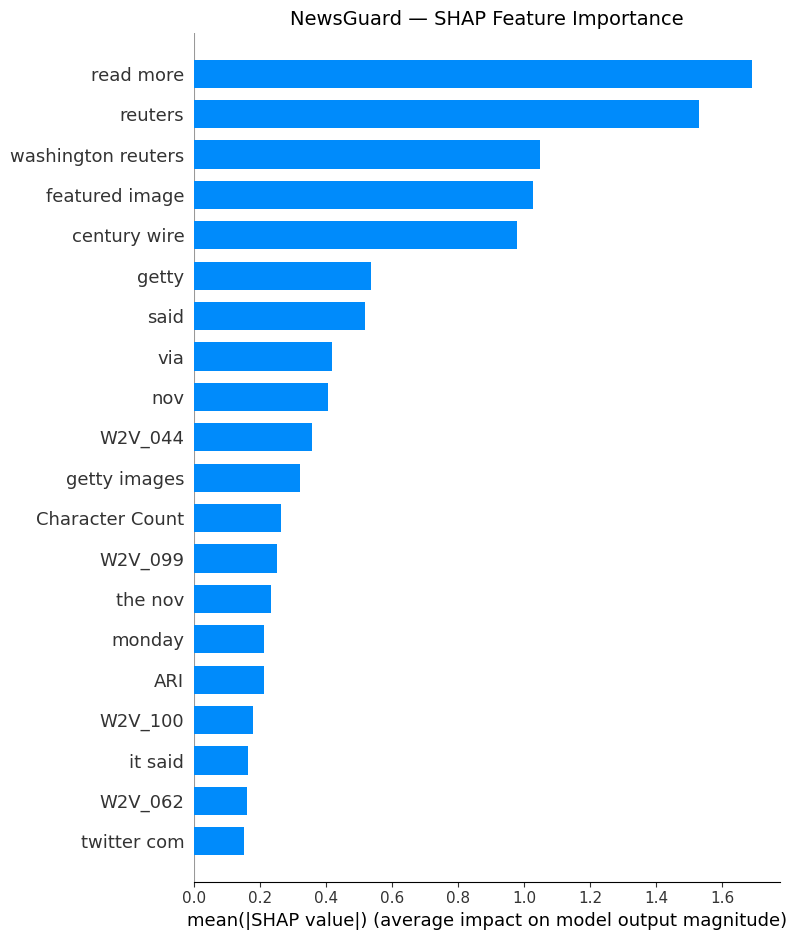

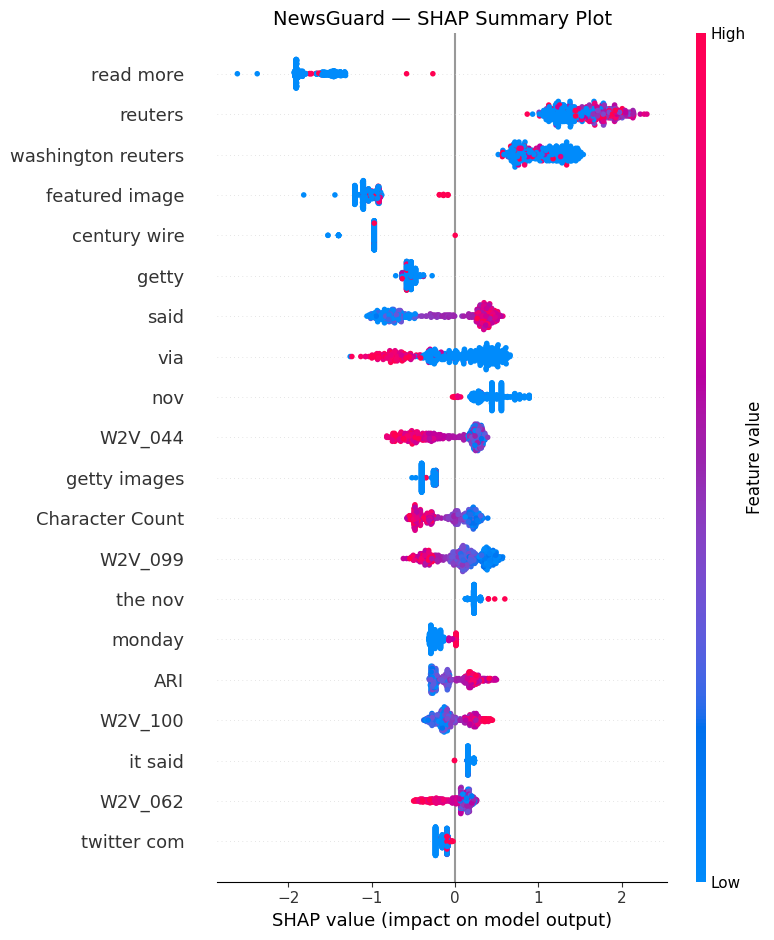


SAVED ARTIFACTS
✓ /content/drive/MyDrive/NewsGuard/results/day_08/shap_feature_importance.csv
✓ /content/drive/MyDrive/NewsGuard/results/day_08/shap_summary_bar.png
✓ /content/drive/MyDrive/NewsGuard/results/day_08/shap_summary_beeswarm.png

✅ SHAP SUMMARY ANALYSIS COMPLETE


In [12]:
# ============================================================
# CELL 7 — SHAP SUMMARY PLOT + TOP FEATURES
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

print("=" * 80)
print("DAY 8 — SHAP SUMMARY ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Results directory
# ------------------------------------------------------------

day8_results_dir = "/content/drive/MyDrive/NewsGuard/results/day_08"
os.makedirs(day8_results_dir, exist_ok=True)

# ------------------------------------------------------------
# Mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

shap_importance = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Top 20 features
# ------------------------------------------------------------

top_20 = shap_importance.head(20)

print("\nTOP 20 MOST IMPORTANT FEATURES")
print("-" * 80)

for i, row in top_20.iterrows():
    print(
        f"{i + 1:02d}. "
        f"{row['Feature']:<35} "
        f"{row['Mean_Absolute_SHAP']:.6f}"
    )

# ------------------------------------------------------------
# Save importance table
# ------------------------------------------------------------

importance_path = os.path.join(
    day8_results_dir,
    "shap_feature_importance.csv"
)

shap_importance.to_csv(
    importance_path,
    index=False
)

# ------------------------------------------------------------
# SHAP summary bar plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap_dense,
    feature_names=shap_feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "NewsGuard — SHAP Feature Importance",
    fontsize=14
)

plt.tight_layout()

summary_bar_path = os.path.join(
    day8_results_dir,
    "shap_summary_bar.png"
)

plt.savefig(
    summary_bar_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# SHAP beeswarm summary plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap_dense,
    feature_names=shap_feature_names,
    max_display=20,
    show=False
)

plt.title(
    "NewsGuard — SHAP Summary Plot",
    fontsize=14
)

plt.tight_layout()

summary_beeswarm_path = os.path.join(
    day8_results_dir,
    "shap_summary_beeswarm.png"
)

plt.savefig(
    summary_beeswarm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert os.path.exists(importance_path)
assert os.path.exists(summary_bar_path)
assert os.path.exists(summary_beeswarm_path)

print("\n" + "=" * 80)
print("SAVED ARTIFACTS")
print("=" * 80)

print("✓", importance_path)
print("✓", summary_bar_path)
print("✓", summary_beeswarm_path)

print("\n" + "=" * 80)
print("✅ SHAP SUMMARY ANALYSIS COMPLETE")
print("=" * 80)

In [13]:
# ============================================================
# CELL 8 — THREE INDIVIDUAL SHAP EXPLANATIONS
# ============================================================

print("=" * 80)
print("DAY 8 — INDIVIDUAL SHAP EXPLANATIONS")
print("=" * 80)

# ------------------------------------------------------------
# Select 3 held-out test samples
# Prefer both Fake and Real examples
# ------------------------------------------------------------

fake_indices = np.where(y_test == 0)[0]
real_indices = np.where(y_test == 1)[0]

selected_indices = [
    int(fake_indices[0]),
    int(real_indices[0]),
    int(fake_indices[1])
]

print("\nSELECTED TEST INDICES")
print("-" * 80)
print(selected_indices)

# ------------------------------------------------------------
# Generate explanations
# ------------------------------------------------------------

individual_explanations = []

for explanation_number, test_index in enumerate(
    selected_indices,
    start=1
):
    x_instance = X_test_shap[test_index].toarray().astype(
        np.float32
    )

    shap_instance = explainer.shap_values(
        x_instance
    )

    prediction_probability = best_xgb.predict_proba(
        x_instance
    )[0, 1]

    prediction = int(
        best_xgb.predict(x_instance)[0]
    )

    actual = int(
        y_test[test_index]
    )

    individual_explanations.append({
        "Explanation": explanation_number,
        "Test_Index": test_index,
        "Actual_Label": actual,
        "Predicted_Label": prediction,
        "Real_Probability": prediction_probability,
        "Credibility_Score": prediction_probability * 100
    })

    # --------------------------------------------------------
    # Force plot
    # --------------------------------------------------------

    force_plot = shap.force_plot(
        explainer.expected_value,
        shap_instance[0],
        x_instance[0],
        feature_names=shap_feature_names,
        matplotlib=False
    )

    force_path = os.path.join(
        day8_results_dir,
        f"shap_force_plot_{explanation_number}.html"
    )

    shap.save_html(
        force_path,
        force_plot
    )

    print(
        f"\nExplanation {explanation_number}"
    )
    print("-" * 80)
    print("Test index:", test_index)
    print("Actual label:", actual)
    print("Predicted label:", prediction)
    print(
        "Real probability:",
        f"{prediction_probability:.6f}"
    )
    print(
        "Credibility score:",
        f"{prediction_probability * 100:.2f}/100"
    )
    print("Saved:", force_path)

# ------------------------------------------------------------
# Save explanation summary
# ------------------------------------------------------------

individual_df = pd.DataFrame(
    individual_explanations
)

individual_path = os.path.join(
    day8_results_dir,
    "shap_individual_explanations.csv"
)

individual_df.to_csv(
    individual_path,
    index=False
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(individual_explanations) == 3

for i in range(1, 4):
    assert os.path.exists(
        os.path.join(
            day8_results_dir,
            f"shap_force_plot_{i}.html"
        )
    )

assert os.path.exists(individual_path)

print("\n" + "=" * 80)
print("SAVED ARTIFACTS")
print("=" * 80)

print("✓ shap_force_plot_1.html")
print("✓ shap_force_plot_2.html")
print("✓ shap_force_plot_3.html")
print("✓ shap_individual_explanations.csv")

print("\n" + "=" * 80)
print("✅ THREE INDIVIDUAL SHAP EXPLANATIONS COMPLETE")
print("=" * 80)

DAY 8 — INDIVIDUAL SHAP EXPLANATIONS

SELECTED TEST INDICES
--------------------------------------------------------------------------------
[1, 0, 8]

Explanation 1
--------------------------------------------------------------------------------
Test index: 1
Actual label: 0
Predicted label: 0
Real probability: 0.005281
Credibility score: 0.53/100
Saved: /content/drive/MyDrive/NewsGuard/results/day_08/shap_force_plot_1.html

Explanation 2
--------------------------------------------------------------------------------
Test index: 0
Actual label: 1
Predicted label: 0
Real probability: 0.257711
Credibility score: 25.77/100
Saved: /content/drive/MyDrive/NewsGuard/results/day_08/shap_force_plot_2.html

Explanation 3
--------------------------------------------------------------------------------
Test index: 8
Actual label: 0
Predicted label: 0
Real probability: 0.000715
Credibility score: 0.07/100
Saved: /content/drive/MyDrive/NewsGuard/results/day_08/shap_force_plot_3.html

SAVED ARTIFAC

In [14]:
# ============================================================
# CELL 9 — DAY 8 FINAL VERIFICATION + SUMMARY
# ============================================================

import os
import json
import pandas as pd
import numpy as np

print("=" * 80)
print("DAY 8 — FINAL SHAP VERIFICATION")
print("=" * 80)

# ------------------------------------------------------------
# Required SHAP artifacts
# ------------------------------------------------------------

required_artifacts = [
    "shap_feature_importance.csv",
    "shap_summary_bar.png",
    "shap_summary_beeswarm.png",
    "shap_force_plot_1.html",
    "shap_force_plot_2.html",
    "shap_force_plot_3.html",
    "shap_individual_explanations.csv"
]

print("\nARTIFACT VERIFICATION")
print("-" * 80)

for artifact in required_artifacts:

    path = os.path.join(
        day8_results_dir,
        artifact
    )

    exists = os.path.exists(path)

    print(
        f"{'✓' if exists else '✗'} {artifact}"
    )

    assert exists, f"Missing artifact: {artifact}"

# ------------------------------------------------------------
# Load and verify feature importance
# ------------------------------------------------------------

importance_df = pd.read_csv(
    os.path.join(
        day8_results_dir,
        "shap_feature_importance.csv"
    )
)

assert importance_df.shape[0] == 615
assert list(importance_df.columns) == [
    "Feature",
    "Mean_Absolute_SHAP"
]

assert importance_df["Feature"].is_unique
assert np.isfinite(
    importance_df["Mean_Absolute_SHAP"]
).all()

# ------------------------------------------------------------
# Load individual explanations
# ------------------------------------------------------------

individual_df = pd.read_csv(
    os.path.join(
        day8_results_dir,
        "shap_individual_explanations.csv"
    )
)

assert individual_df.shape[0] == 3

# ------------------------------------------------------------
# Final SHAP summary
# ------------------------------------------------------------

day8_summary = {
    "day": 8,
    "task": "SHAP Explainability",
    "model": "XGBoost",
    "model_features": int(best_xgb.n_features_in_),
    "shap_samples": int(X_shap_dense.shape[0]),
    "shap_features": int(shap_values.shape[1]),
    "top_feature": str(
        importance_df.iloc[0]["Feature"]
    ),
    "top_feature_mean_abs_shap": float(
        importance_df.iloc[0]["Mean_Absolute_SHAP"]
    ),
    "individual_explanations": 3,
    "summary_bar_plot": True,
    "summary_beeswarm_plot": True,
    "force_plots": 3,
    "status": "COMPLETE"
}

summary_path = os.path.join(
    day8_results_dir,
    "day_08_shap_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        day8_summary,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DAY 8 SHAP SUMMARY")
print("=" * 80)

for key, value in day8_summary.items():
    print(f"{key}: {value}")

print("\n" + "=" * 80)
print("SAVED")
print("=" * 80)

print("✓", summary_path)

print("\n" + "=" * 80)
print("✅ DAY 8 SHAP EXPLAINABILITY COMPLETE")
print("=" * 80)

DAY 8 — FINAL SHAP VERIFICATION

ARTIFACT VERIFICATION
--------------------------------------------------------------------------------
✓ shap_feature_importance.csv
✓ shap_summary_bar.png
✓ shap_summary_beeswarm.png
✓ shap_force_plot_1.html
✓ shap_force_plot_2.html
✓ shap_force_plot_3.html
✓ shap_individual_explanations.csv

DAY 8 SHAP SUMMARY
day: 8
task: SHAP Explainability
model: XGBoost
model_features: 615
shap_samples: 500
shap_features: 615
top_feature: read more
top_feature_mean_abs_shap: 1.6897715
individual_explanations: 3
summary_bar_plot: True
summary_beeswarm_plot: True
force_plots: 3
status: COMPLETE

SAVED
✓ /content/drive/MyDrive/NewsGuard/results/day_08/day_08_shap_summary.json

✅ DAY 8 SHAP EXPLAINABILITY COMPLETE
